## Name: Vedant Shirgaonkar
## Roll No.: D114   
## SAP ID: 60009230002

In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import matplotlib.pyplot as plt

In [ ]:
iris = load_iris()
X = iris.data
y = iris.target.reshape(-1, 1)

encoder = OneHotEncoder(sparse_output=False)
y_encoded = encoder.fit_transform(y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42)

In [ ]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def accuracy(y_true, y_pred):
    return np.mean(np.argmax(y_true, axis=1) == np.argmax(y_pred, axis=1))

In [ ]:
input_dim = X_train.shape[1]   # 4 features
hidden_dim = 6                 # hidden neurons
output_dim = y_train.shape[1]  # 3 classes
lr = 0.05                      # learning rate
epochs = 500                   # training iterations

# Weight initialization
np.random.seed(42)
W1 = np.random.randn(input_dim, hidden_dim)
b1 = np.zeros((1, hidden_dim))
W2 = np.random.randn(hidden_dim, output_dim)
b2 = np.zeros((1, output_dim))

In [ ]:
mse_list = []
acc_list = []

for epoch in range(epochs):
    # Forward pass
    z1 = np.dot(X_train, W1) + b1
    a1 = sigmoid(z1)
    z2 = np.dot(a1, W2) + b2
    a2 = softmax(z2)

    # Compute loss and accuracy
    loss = mse(y_train, a2)
    acc = accuracy(y_train, a2)
    mse_list.append(loss)
    acc_list.append(acc)

    # Backpropagation
    error_output = y_train - a2
    dW2 = np.dot(a1.T, error_output)
    db2 = np.sum(error_output, axis=0, keepdims=True)

    error_hidden = np.dot(error_output, W2.T) * sigmoid_derivative(a1)
    dW1 = np.dot(X_train.T, error_hidden)
    db1 = np.sum(error_hidden, axis=0, keepdims=True)

    # Update weights
    W1 += lr * dW1
    b1 += lr * db1
    W2 += lr * dW2
    b2 += lr * db2

    if (epoch+1) % 50 == 0:
        print(f"Epoch {epoch+1}/{epochs} - Loss: {loss:.4f} - Accuracy: {acc:.4f}")

Epoch 50/500 - Loss: 0.0126 - Accuracy: 0.9583
Epoch 100/500 - Loss: 0.0119 - Accuracy: 0.9667
Epoch 150/500 - Loss: 0.0120 - Accuracy: 0.9583
Epoch 200/500 - Loss: 0.0114 - Accuracy: 0.9750
Epoch 250/500 - Loss: 0.0109 - Accuracy: 0.9750
Epoch 300/500 - Loss: 0.0107 - Accuracy: 0.9833
Epoch 350/500 - Loss: 0.0105 - Accuracy: 0.9833
Epoch 400/500 - Loss: 0.0104 - Accuracy: 0.9833
Epoch 450/500 - Loss: 0.0103 - Accuracy: 0.9833
Epoch 500/500 - Loss: 0.0102 - Accuracy: 0.9833


In [ ]:
z1 = np.dot(X_test, W1) + b1
a1 = sigmoid(z1)
z2 = np.dot(a1, W2) + b2
y_pred = softmax(z2)

test_acc = accuracy(y_test, y_pred)
print("\nFinal Test Accuracy:", test_acc)


Final Test Accuracy: 1.0


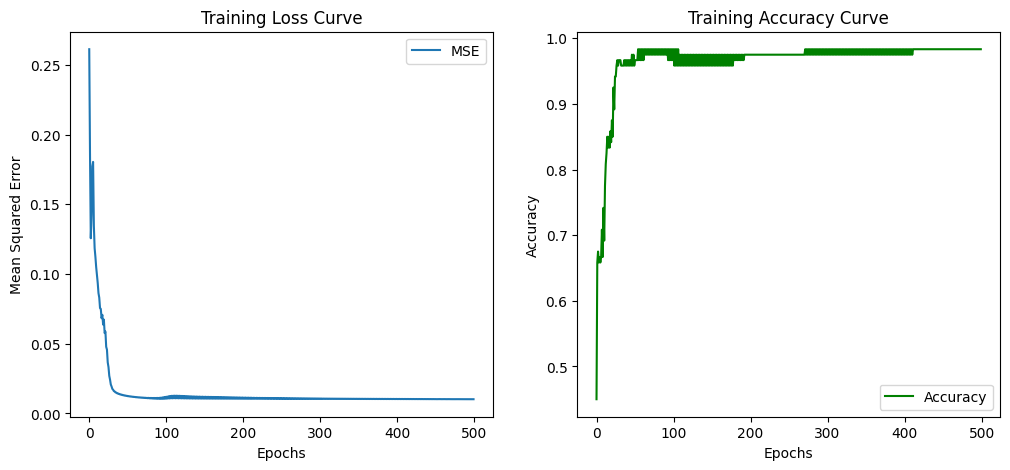

In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(mse_list, label="MSE")
plt.xlabel("Epochs")
plt.ylabel("Mean Squared Error")
plt.title("Training Loss Curve")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(acc_list, label="Accuracy", color="green")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training Accuracy Curve")
plt.legend()

plt.show()